<a href="https://colab.research.google.com/github/elisabon75/ECM_2526_FinalProject/blob/main/Manipulation_donnees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import seaborn as sn

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
!ls "/content/drive/MyDrive/DATA FINAL PROJECT"

 4d6df9b7c188aeeb213c06d0fd4b2fea.zip
'Brouillon Data .gdoc'
'Cahier des charges.gdoc'
 dutch_ttf_natural_gas.csv
 dutch_ttf_natural_gas.gsheet
'elev_ens_0.1deg_reg_v31.0e (1).nc'
 european_wholesale_electricity_price_data_daily.csv
 european_wholesale_electricity_price_data_monthly.csv
 Manipulation_donnees.ipynb
 tg_ens_mean_0.1deg_reg_2011-2024_v31.0e.nc
 Tg-runningyear.nc


In [7]:
# J'importe dataset prix élec daily en Europe
import pandas as pd

df_elec_daily = pd.read_csv("/content/drive/MyDrive/DATA FINAL PROJECT/european_wholesale_electricity_price_data_daily.csv")
df_elec_daily.head()

,Country,ISO3 Code,Date,Price (EUR/MWhe)
0,Austria,AUT,2015-01-01,22.34
1,Belgium,BEL,2015-01-01,36.56
2,Czechia,CZE,2015-01-01,20.60
3,Denmark,DNK,2015-01-01,15.51
4,Estonia,EST,2015-01-01,24.51


In [8]:
# J'importe dataset prix élec monthly en Europe
import pandas as pd

df_elec_monthly = pd.read_csv("/content/drive/MyDrive/DATA FINAL PROJECT/european_wholesale_electricity_price_data_monthly.csv")
df_elec_monthly.head()

,Country,ISO3 Code,Date,Price (EUR/MWhe)
0,Austria,AUT,2015-01-01,29.94
1,Belgium,BEL,2015-01-01,42.33
2,Czechia,CZE,2015-01-01,29.47
3,Denmark,DNK,2015-01-01,27.12
4,Estonia,EST,2015-01-01,33.84


In [9]:
# Trier par date
df_elec_daily = df_elec_daily.sort_index()
df_elec_monthly = df_elec_monthly.sort_index()

In [10]:
# Voir les données manquantes

df_elec_daily.isna().sum()
df_elec_monthly.isna().sum()

,0
Country,0
ISO3 Code,0
Date,0
Price (EUR/MWhe),6


In [11]:
# Remplir les trous

df_elec_daily = df_elec_daily.interpolate()
df_elec_monthly = df_elec_monthly.interpolate()

/tmp/ipython-input-713374141.py:3: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_elec_daily = df_elec_daily.interpolate()
/tmp/ipython-input-713374141.py:4: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_elec_monthly = df_elec_monthly.interpolate()


In [12]:
df_elec_daily.describe()

,Price (EUR/MWhe)
count,112548.000000
mean,78.611371
std,74.340737
min,-202.290000
25%,36.500000
50%,52.785000
75%,95.920000
max,888.090000


In [13]:
df_elec_daily.head()

,Country,ISO3 Code,Date,Price (EUR/MWhe)
0,Austria,AUT,2015-01-01,22.34
1,Belgium,BEL,2015-01-01,36.56
2,Czechia,CZE,2015-01-01,20.60
3,Denmark,DNK,2015-01-01,15.51
4,Estonia,EST,2015-01-01,24.51


In [37]:
df_elec_daily['Date'] = pd.to_datetime(df_elec_daily['Date'])
df_elec_monthly['Date'] = pd.to_datetime(df_elec_monthly['Date'])

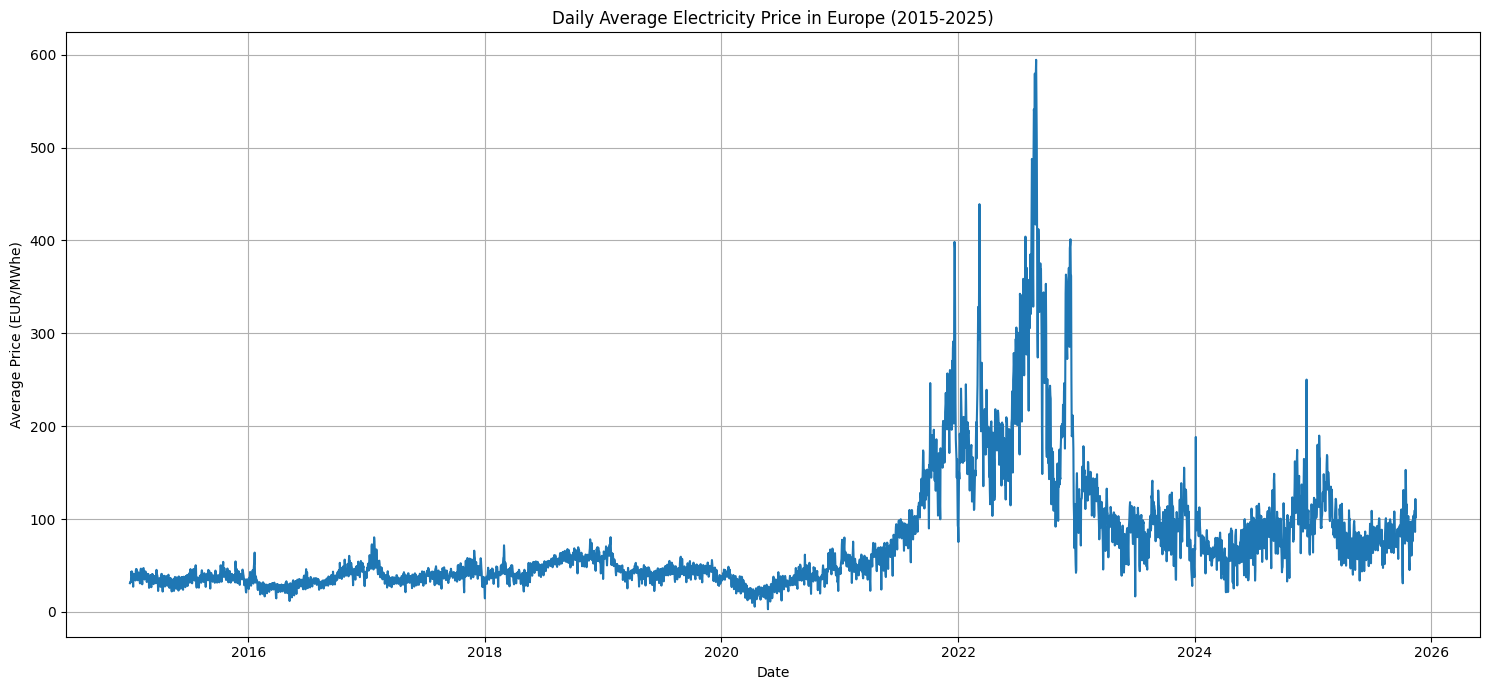

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the daily average price across all countries
daily_avg_price = df_elec_daily.groupby('Date')['Price (EUR/MWhe)'].mean().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y='Price (EUR/MWhe)', data=daily_avg_price)
plt.title('Daily Average Electricity Price in Europe (2015-2025)')
plt.xlabel('Date')
plt.ylabel('Average Price (EUR/MWhe)')
plt.grid(True)
plt.tight_layout()
plt.show()

Données météorologiques (partie coco)



1) Données d'élévation ?

In [16]:
!pip install netCDF4
import netCDF4 as nc

df_meteotest1 = nc.Dataset("/content/drive/MyDrive/DATA FINAL PROJECT/elev_ens_0.1deg_reg_v31.0e (1).nc")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 43.9 MB/s eta 0:00:00


In [17]:
print(df_meteotest1.variables.keys())


dict_keys(['longitude', 'latitude', 'elevation'])


2. Avec les données de températures de l'année en cours

In [18]:
df_meteotest2 = nc.Dataset("/content/drive/MyDrive/DATA FINAL PROJECT/Tg-runningyear.nc")

In [19]:
print(df_meteotest2.variables.keys())

dict_keys(['time', 'longitude', 'latitude', 'tg'])


In [20]:
import numpy as np
data = df_meteotest2.variables['tg'][:]
has_nan = np.isnan(data).any()
print(has_nan)

False


In [21]:
df_meteotest3 = nc.Dataset("/content/drive/MyDrive/DATA FINAL PROJECT/tg_ens_mean_0.1deg_reg_2011-2024_v31.0e.nc")

In [22]:
print(df_meteotest3.variables.keys())

dict_keys(['longitude', 'latitude', 'time', 'tg'])


#####**GAZ**. Avec le prix du gaz TTF (Title Transfer Facility), prix de référence du gaz naturel en Europe, fixé au hub néerlandais

In [23]:
# J'importe dataset prix gaz TTF daily en Europe / Pays-Bas c'est le hub
import pandas as pd

df_gas_daily = pd.read_csv("/content/drive/MyDrive/DATA FINAL PROJECT/dutch_ttf_natural_gas.csv")
df_gas_daily.head()

,Date,Dernier ((EUR/MWh),Ouv.,Plus Haut,Plus Bas
0,23/10/2017,"18,09","18,09","18,09","18,09"
1,24/10/2017,"17,96","17,96","17,96","17,96"
2,25/10/2017,"18,11","18,11","18,11","18,11"
3,26/10/2017,"18,07","18,07","18,07","18,07"
4,27/10/2017,"18,15","18,15","18,15","18,15"


In [31]:
print(f"df_elec_daily Date Range: {df_elec_daily['Date'].min()} to {df_elec_daily['Date'].max()}")

df_elec_daily Date Range: 2015-01-01 00:00:00 to 2025-11-14 00:00:00


In [32]:
print(f"df_elec_monthly Date Range: {df_elec_monthly['Date'].min()} to {df_elec_monthly['Date'].max()}")

df_elec_monthly Date Range: 2015-01-01 00:00:00 to 2025-11-01 00:00:00


In [33]:
print(f"df_gas_daily Date Range: {df_gas_daily['Date'].min()} to {df_gas_daily['Date'].max()}")

df_gas_daily Date Range: 2017-10-23 00:00:00 to 2025-11-19 00:00:00


La période de temps en commun pour tous les datasets est donc du 23 octobre 2017 au 1er novembre 2025. Cela représente environ 8 ans de données superposées.


In [24]:
# Trier par date
df_gas_daily = df_gas_daily.sort_index()

In [25]:
# Voir les données manquantes

df_gas_daily.isna().sum()

,0
Date,0
Dernier ((EUR/MWh),0
Ouv.,0
Plus Haut,0
Plus Bas,0


In [26]:
# Remplir les trous

# Convert 'Date' column to datetime
df_gas_daily['Date'] = pd.to_datetime(df_gas_daily['Date'], format='%d/%m/%Y')

# Convert numeric columns to appropriate types, replacing ',' with '.'
for col in ['Dernier ((EUR/MWh)', 'Ouv.', ' Plus Haut', 'Plus Bas']:
    df_gas_daily[col] = df_gas_daily[col].str.replace(',', '.').astype(float)

df_gas_daily = df_gas_daily.interpolate()

# Check the interpolation and data types
print(df_gas_daily.isna().sum())
print(df_gas_daily.info())

Date                  0
Dernier ((EUR/MWh)    0
Ouv.                  0
 Plus Haut            0
Plus Bas              0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2036 entries, 0 to 2035
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                2036 non-null   datetime64[ns]
 1   Dernier ((EUR/MWh)  2036 non-null   float64       
 2   Ouv.                2036 non-null   float64       
 3    Plus Haut          2036 non-null   float64       
 4   Plus Bas            2036 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 79.7 KB
None


In [27]:
df_gas_daily.describe()

,Date,Dernier ((EUR/MWh),Ouv.,Plus Haut,Plus Bas
count,2036,2036.000000,2036.000000,2036.000000,2036.000000
mean,2021-11-07 07:32:39.135559936,42.045734,42.034407,42.583774,41.520453
min,2017-10-23 00:00:00,3.510000,3.700000,3.850000,3.500000
25%,2019-10-29 18:00:00,17.880000,17.850000,17.982500,17.797500
50%,2021-11-04 12:00:00,29.662500,29.782500,30.425000,29.172500
75%,2023-11-14 06:00:00,43.472000,43.660000,44.382500,42.675000
max,2025-11-19 00:00:00,339.195000,339.195000,339.195000,339.195000
std,NaN,42.685462,42.625313,42.827061,42.456484


In [28]:
df_gas_daily.head()

,Date,Dernier ((EUR/MWh),Ouv.,Plus Haut,Plus Bas
0,2017-10-23,18.09,18.09,18.09,18.09
1,2017-10-24,17.96,17.96,17.96,17.96
2,2017-10-25,18.11,18.11,18.11,18.11
3,2017-10-26,18.07,18.07,18.07,18.07
4,2017-10-27,18.15,18.15,18.15,18.15


In [29]:
df_gas_daily['Date'] = pd.to_datetime(df_gas_daily['Date'])

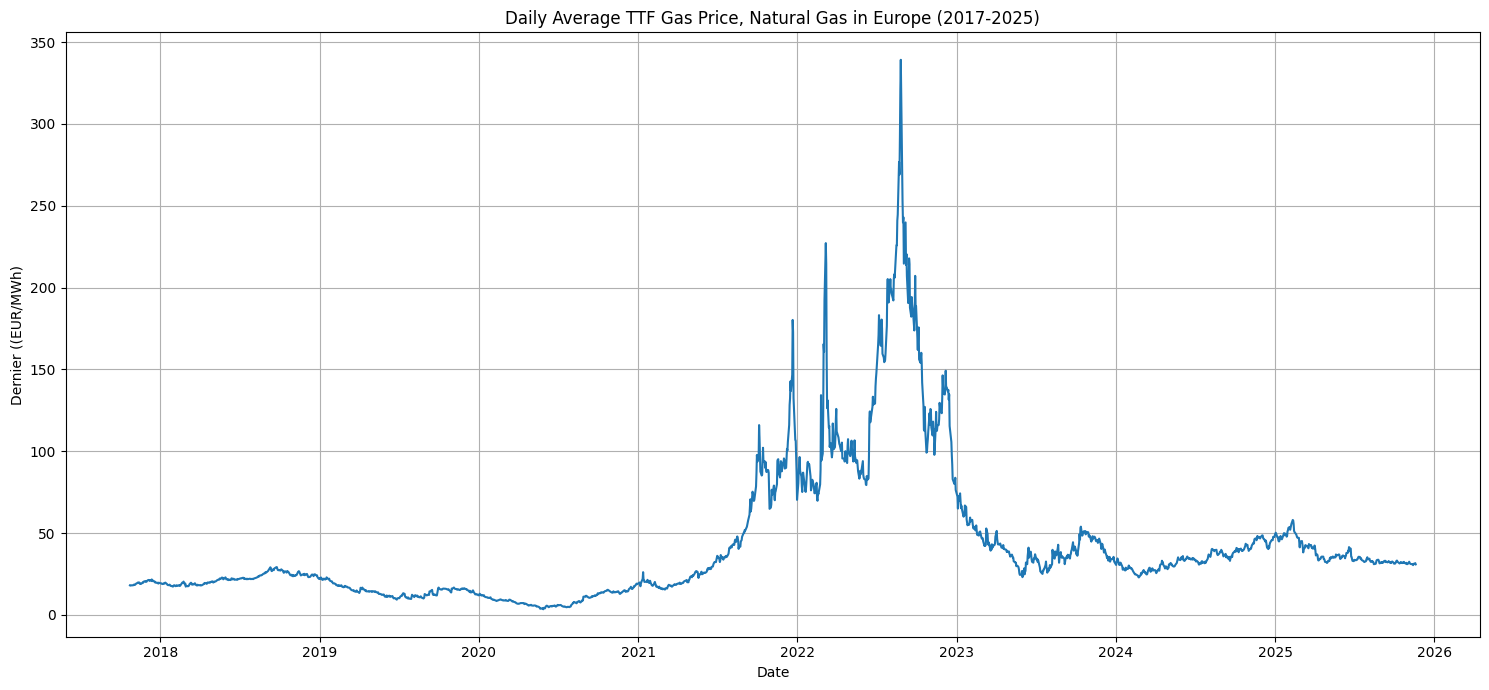

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the daily average price across all countries
daily_avg_price_gas = df_gas_daily.groupby('Date')['Dernier ((EUR/MWh)'].mean().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y='Dernier ((EUR/MWh)', data=daily_avg_price_gas)
plt.title('Daily Average TTF Gas Price, Natural Gas in Europe (2017-2025)')
plt.xlabel('Date')
plt.ylabel('Dernier ((EUR/MWh)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
import pandas as pd

# Merge the daily average electricity and gas prices on the 'Date' column
merged_prices = pd.merge(daily_avg_price, daily_avg_price_gas, on='Date', how='inner')

# Define the common period identified earlier
start_date = '2017-10-23'
end_date = '2025-11-01'

# Filter the merged DataFrame to this common period
merged_prices_filtered = merged_prices[(merged_prices['Date'] >= start_date) & (merged_prices['Date'] <= end_date)]

display(merged_prices_filtered.head())

,Date,Price (EUR/MWhe),Dernier ((EUR/MWh)
0,2017-10-23,47.945000,18.09
1,2017-10-24,44.959286,17.96
2,2017-10-25,45.226786,18.11
3,2017-10-26,48.641429,18.07
4,2017-10-27,46.429643,18.15


In [35]:
# Calculate the correlation between electricity price and gas price
correlation = merged_prices_filtered['Price (EUR/MWhe)'].corr(merged_prices_filtered['Dernier ((EUR/MWh)'])

print(f"La corrélation entre le prix quotidien de l'électricité et le prix quotidien du gaz TTF est : {correlation:.2f}")

La corrélation entre le prix quotidien de l'électricité et le prix quotidien du gaz TTF est : 0.95


Un coefficient de corrélation proche de 1 indique une forte corrélation positive.
Ici nous avons une forte corrélation, ce qui fait sens.

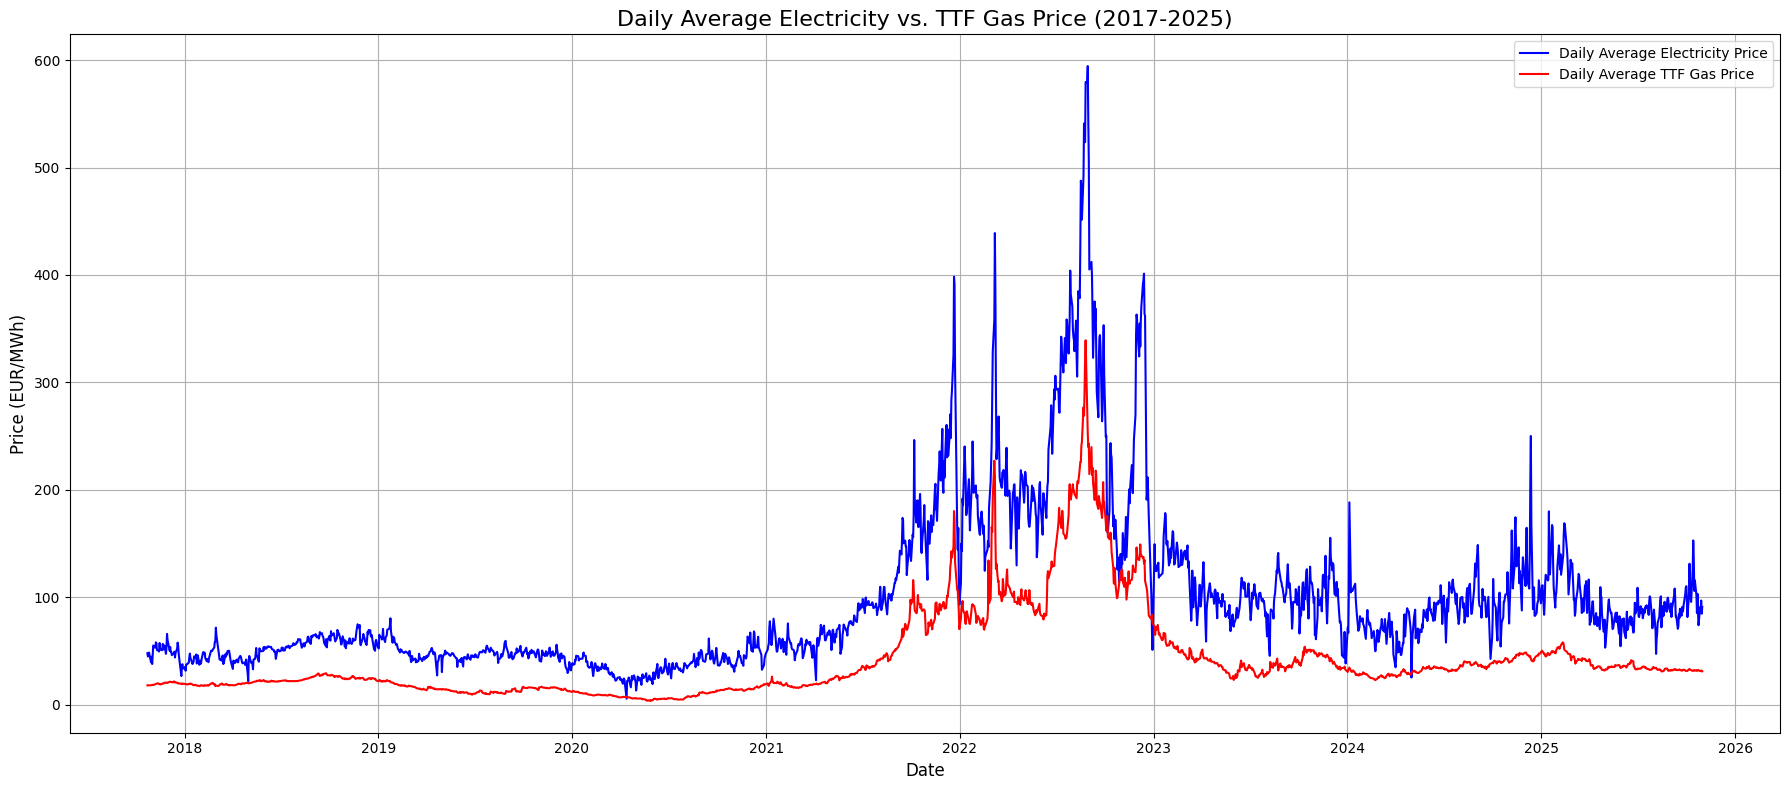

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 8))

sns.lineplot(x='Date', y='Price (EUR/MWhe)', data=merged_prices_filtered, label='Daily Average Electricity Price', color='blue')
sns.lineplot(x='Date', y='Dernier ((EUR/MWh)', data=merged_prices_filtered, label='Daily Average TTF Gas Price', color='red')

plt.title('Daily Average Electricity vs. TTF Gas Price (2017-2025)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (EUR/MWh)', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()